#### Brain Tumor Classification

## <a id='tumor'> What is Brain Tumor?</a>

> A brain tumor occurs when abnormal cells form within the brain. There are two main types of tumors: cancerous (malignant) tumors and benign tumors. Cancerous tumors can be divided into primary tumors, which start within the brain, and secondary tumors, which have spread from elsewhere, known as brain metastasis tumors. All types of brain tumors may produce symptoms that vary depending on the part of the brain involved. These symptoms may include headaches, seizures, problems with vision, vomiting and mental changes. The headache is classically worse in the morning and goes away with vomiting. Other symptoms may include difficulty walking, speaking or with sensations. As the disease progresses, unconsciousness may occur.
>
> ![](https://upload.wikimedia.org/wikipedia/commons/5/5f/Hirnmetastase_MRT-T1_KM.jpg)
>
> *Brain metastasis in the right cerebral hemisphere from lung cancer, shown on magnetic resonance imaging.*

Source: [Wikipedia](https://en.wikipedia.org/wiki/Brain_tumor)

In [ ]:
import os
import keras
from keras.models import Sequential
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense
from keras.layers import BatchNormalization
from keras.layers import Dropout

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('dark_background')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

In [ ]:
from PIL import Image


In [ ]:
#Importing the dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
encoder = OneHotEncoder()

In [ ]:
data=[]
paths=[]
result=[]

# Fit the encoder with all possible categories (0 and 1) before transforming
encoder.fit(np.array([0, 1]).reshape(-1, 1))

for r,d,f in os.walk(r'/content/drive/My Drive/brain_tumor_dataset/yes'):
  for file in f:
    if '.jpg' in file:
      paths.append(os.path.join(r,file))

for path in paths:
  img = Image.open(path)
  img = img.resize((128,128))
  img = np.array(img)
  if img.shape == (128,128,3):
      data.append(np.array(img))
      result.append(encoder.transform([[0]]).toarray())

In [ ]:
paths=[]


for r,d,f in os.walk(r'/content/drive/My Drive/brain_tumor_dataset/no'):
  for file in f:
    if '.jpg' in file:
      paths.append(os.path.join(r,file))

for path in paths:
  img = Image.open(path)
  img = img.resize((128,128))
  img = np.array(img)
  if img.shape == (128,128,3):
    data.append(np.array(img))
    result.append(encoder.transform([[1]]).toarray())

In [ ]:
data = np.array(data)
data.shape

(139, 128, 128, 3)

In [ ]:
result = np.array(result)
result = result.reshape(139,2)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(data, result, test_size=0.2, shuffle=True, random_state=0)


In [ ]:
print("No of image in training set : ", X_train.shape[0])

No of image in training set :  111


In [ ]:
print("No of image in test set : ", X_test.shape[0])

No of image in test set :  28


##### Building the Model
we are constructing an AI model that uses a Convolutional Neural Network (CNN), which is particularly good for image recognition tasks. Our model begins with two convolutional layers that have 32 filters each; these layers are designed to detect basic patterns in the brain MRI images, like edges and textures.

In [ ]:
model = Sequential()

model.add(Conv2D(32, kernel_size=(2,2),input_shape=(128,128,3),padding='same'))
model.add(Conv2D(32, kernel_size=(2,2),padding='same',activation='relu'))

model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, kernel_size=(2,2),padding='same',activation='relu'))
model.add(Conv2D(64, kernel_size=(2,2),padding='same',activation='relu'))

model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2)))
model.add(Dense(2,activation='softmax'))

model.add(Flatten())

model.add(Dense(512,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(2,activation='softmax'))

model.compile(loss = 'categorical_crossentropy', optimizer = 'Adamax')
print(model.summary())


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 32)   │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 64)     │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32, 32, 2)      │           130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,079,876 (4.12 MB)

 Trainable params: 1,079,684 (4.12 MB)

 Non-trainable params: 192 (768.00 B)

None


In [ ]:
history = model.fit(X_train, y_train, batch_size=32, epochs=30, verbose=1, validation_data=(X_test, y_test))

Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - loss: 1.5785 - val_loss: 2.2324
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - loss: 1.5621 - val_loss: 1.8993
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - loss: 1.3867 - val_loss: 0.9892
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - loss: 1.0552 - val_loss: 1.1159
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - loss: 0.9015 - val_loss: 0.8100
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - loss: 0.8526 - val_loss: 0.7232
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - loss: 0.7550 - val_loss: 0.7326
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - loss: 0.7324 - val_loss: 0.9299
Epoch 9/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - loss: 0.6171 - val_loss: 0.7562
Epoch 10/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - loss: 0.5661 - val_loss: 0.6293
Epoch 11/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - loss: 0.5111 - val_loss: 0.8069
Epoch 12/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - loss: 0.4811 - val_loss: 0.7581
Epoch 13/30
4/4 ━━━━

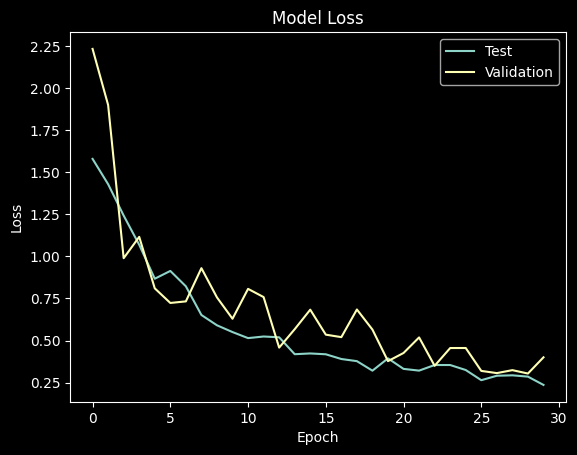

In [ ]:
#plotting losses
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Test', 'Validation'], loc='upper right')
plt.show()

In [ ]:
def names(number):
    if number == 0:
        return 'Tumor'
    else:
        return 'No Tumor'

71.82256% Confidence This Is No Tumor


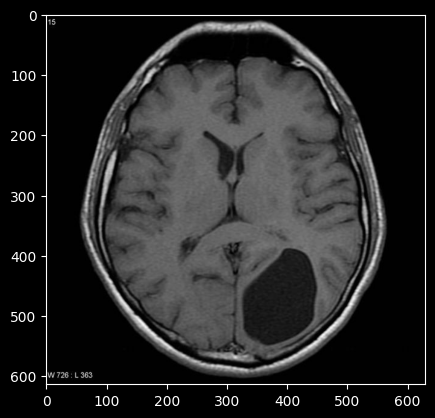

In [ ]:
# testing the model
from matplotlib.pyplot import imshow
img = Image.open(r"/content/drive/My Drive/no/N11.jpg")
x = np.array(img.resize((128,128)))
x = x.reshape(1,128,128,3)
res = model.predict_on_batch(x)
classification = np.where(res == np.amax(res))[1][0]
imshow(img)


print(str(res[0][classification]*100) + '% Confidence This Is ' + names(classification))

80.35435% Confidence This Is A Tumor


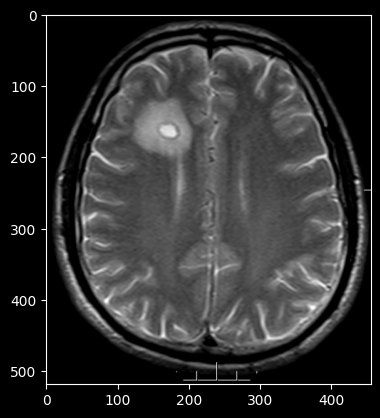

In [ ]:
from matplotlib.pyplot import imshow
img = Image.open(r"/content/drive/My Drive/yes/Y3.jpg")
x = np.array(img.resize((128,128)))
x = x.reshape(1,128,128,3)
res = model.predict_on_batch(x)
classification = np.where(res == np.amax(res))[1][0]
imshow(img)
print(str(res[0][classification]*100) + '% Confidence This Is A ' + names(classification))


In [ ]:
import gradio as gr

In [ ]:
#@title Provide a title for your app:
heading_title = "Brain Tumor Classification app" # @param {type:"string"}

In [ ]:
#@title
num_examples = 2 # @param {type:"slider", min:1, max:6, step:1}

example_path_1:  /content/drive/My Drive/no/N11.jpg
example_path_2:  /content/drive/My Drive/yes/Y3.jpg


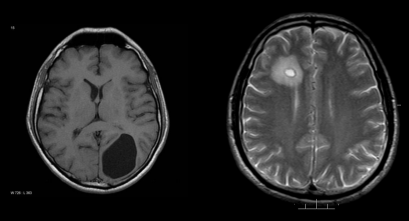

In [ ]:
#@title Enter the paths for the example images that you want displayed in your app by default. The user can use these images to quickly and easily test the model. Note: You can get the path for the file from the left sidebar. Simply run the code below, select the image file you want to include from its folder, right-click and select 'Copy path'. Then paste the path in the input box displayed:
from matplotlib import pyplot as plt
from PIL import Image

examples=[]
for i in range(num_examples):
  example_path = input(f"example_path_{i+1}:  ")
  examples.append(example_path)

#Displaying the selected images side by side
rows = 1
plt.figure(figsize=(16, 8))
for num, x in enumerate(examples):
    img = Image.open(x)
    plt.subplot(rows,6,num+1)
   # plt.title(x.split('.')[0])
    plt.axis('off')
    plt.imshow(img)

In [ ]:
#@title You can also add some description and explanation to your app's interace if you want. Go ahead and specify some text for the description and the long description (if you want to):
desc = "Brain tumor app. Let's learn!" # @param {type:"string"}
long_desc = "Select an image or upload one to predict if brain tumor is present or not" # @param {type:"string"}

In [ ]:
import gradio as gr

#@title Select a Theme for Gradio Interface:
theme_selection = "Glass" # @param ["Base", "Default", "Glass", "Monochrome", "Soft"]

theme_dict = {
    "Base": gr.themes.Base(),
    "Default": gr.themes.Default(),
    "Glass": gr.themes.Glass(),
    "Monochrome": gr.themes.Monochrome(),
    "Soft": gr.themes.Soft()
}

# The selected theme is determined by the user's dropdown selection
selected_theme = theme_dict[theme_selection]

# Now you can use the selected_theme variable when you create your Gradio interface

In [ ]:
def recognize_image(image):
    # Resize the image to the expected dimensions
    img = Image.fromarray(image).resize((128, 128))
    # Convert the image to a NumPy array
    x = np.array(img)
    # Reshape the image to match the model input
    x = x.reshape(1, 128, 128, 3)

    # Make a prediction
    res = model.predict_on_batch(x)
    classification = np.where(res == np.amax(res))[1][0]

    # Map the class index to the actual class name (assuming you have a list of class names)
    class_names = ['No Tumor', 'Tumor']  # Example class names, update according to your model
    result = f"{names(classification)}"

    return result

In [ ]:
# Assuming recognize_image, examples, heading_title, desc, long_desc, and selected_theme are defined elsewhere.

# Update the import for components
image = gr.Image()
label = gr.Label()

# Create the interface with the updated component imports
iface = gr.Interface(
    fn=recognize_image,
    inputs=image,
    outputs=label,
    examples=examples,
    title=heading_title,
    description=desc,
    article=long_desc,
    theme=selected_theme  # Make sure this is defined based on user selection as explained in previous messages
)

iface.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://54e29cfbfd428e1552.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
